# Apprentissage (Linear Regression)

### Données linéaires bruitées

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(123)

In [3]:
m = 50
X = 2 * torch.randn(m, 1)
y = 4 + 3 * X + torch.randn(m, 1)

In [4]:
y

tensor([[  5.7655],
        [  1.8508],
        [  2.1345],
        [  2.0955],
        [  3.7688],
        [  9.0499],
        [  2.6186],
        [  1.2763],
        [  7.6539],
        [ -3.2315],
        [  8.0375],
        [ -4.3416],
        [  5.5165],
        [ 13.9243],
        [  6.4146],
        [  5.5635],
        [  4.5421],
        [ -1.2956],
        [  2.5915],
        [  9.9958],
        [ 13.2690],
        [ 10.0591],
        [ 13.3746],
        [  3.5681],
        [  7.8820],
        [ -6.1557],
        [  9.2043],
        [ -3.6001],
        [ -2.3302],
        [  4.5799],
        [  0.0829],
        [-14.3238],
        [ -6.0412],
        [  6.0334],
        [ -4.3749],
        [ 10.7846],
        [ -3.5964],
        [ 11.1190],
        [  9.7326],
        [  6.0280],
        [  1.5638],
        [-10.1672],
        [  2.2378],
        [  9.8954],
        [ -1.4170],
        [ -2.9471],
        [  4.3963],
        [  4.4538],
        [ 11.6018],
        [  1.6718]])

## Exercice : Trouver à la main les paramètres theta qui fonctionne

In [5]:
from ipywidgets import interact, FloatSlider

# Function to update plot
def plot_line(theta0, theta1):
    plt.figure(figsize=(8,5))
    plt.plot(X.numpy(), y.numpy(), "b.", label="Data")
    y_pred = theta0 + theta1 * X.numpy()
    plt.plot(X.numpy(), y_pred, "r-", linewidth=2, label=f"y = {theta0:.2f} + {theta1:.2f}x")
    plt.xlabel("$x$", fontsize=14)
    plt.ylabel("$y$", rotation=0, fontsize=14)
    plt.axis([0, 2, 0, 15])
    plt.legend()
    plt.show()

# Interactive sliders
interact(
    plot_line,
    theta0=FloatSlider(value=0, min=0, max=10, step=0.1),
    theta1=FloatSlider(value=0, min=0, max=10, step=0.1)
)

interactive(children=(FloatSlider(value=0.0, description='theta0', max=10.0), FloatSlider(value=0.0, descripti…

<function __main__.plot_line(theta0, theta1)>

### Via Scikit-Learn (rappel)

In [6]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.8371556], dtype=float32), array([[3.0681522]], dtype=float32))

## Solution : Descente de Gradient

### Batch gradient descent

In [7]:
# Exercice 2

# Ajouter une colonne de 1 au vecteur X afin qu'on puisse le multiplier par theta -> Voir torch.hstack et torch.ones
# Définir : eta (learning rate) = 10 , nombre d'epochs = 100, thetas (initialisation) -> voir torch.randn
# Instancier une boucle où à chaque itération :
#   Calcul du gradient -> voir slide et torch.matmul ou l'opérateur @
#   Mise à jour de thetas -> voir slide

m = X.shape[0]

X_b = torch.hstack([X, torch.ones((m, 1))])
eta = 0.1
n_epochs = 100
thetas = torch.randn(2, 1)

for i in range(n_epochs):
    gradients = 2/m * torch.matmul(X_b.T, torch.matmul(X_b, thetas)-y)
    thetas = thetas - eta*gradients
    print(thetas)

tensor([[2.3740],
        [0.7159]])
tensor([[2.8370],
        [1.3208]])
tensor([[2.9501],
        [1.8177]])
tensor([[2.9874],
        [2.2183]])
tensor([[3.0063],
        [2.5398]])
tensor([[3.0192],
        [2.7976]])
tensor([[3.0290],
        [3.0041]])
tensor([[3.0368],
        [3.1696]])
tensor([[3.0431],
        [3.3023]])
tensor([[3.0481],
        [3.4085]])
tensor([[3.0520],
        [3.4937]])
tensor([[3.0552],
        [3.5619]])
tensor([[3.0578],
        [3.6166]])
tensor([[3.0599],
        [3.6604]])
tensor([[3.0615],
        [3.6956]])
tensor([[3.0628],
        [3.7237]])
tensor([[3.0639],
        [3.7462]])
tensor([[3.0647],
        [3.7643]])
tensor([[3.0654],
        [3.7788]])
tensor([[3.0660],
        [3.7904]])
tensor([[3.0664],
        [3.7997]])
tensor([[3.0667],
        [3.8071]])
tensor([[3.0670],
        [3.8131]])
tensor([[3.0672],
        [3.8179]])
tensor([[3.0674],
        [3.8217]])
tensor([[3.0676],
        [3.8248]])
tensor([[3.0677],
        [3.8272]])
t

tensor([[3.0682],
        [3.8372]])


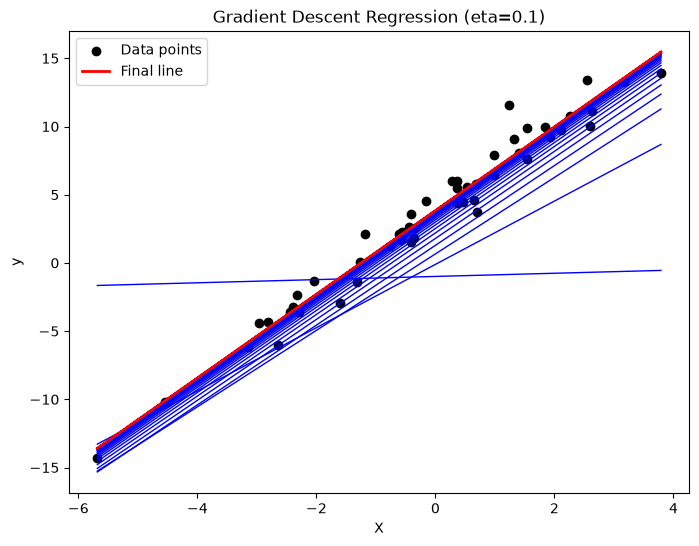

In [8]:
# Suite exercice

# Réaliser une fonction permettant de visualiser les différentes droites trouvées à chaque epoch. 
# Cette fonction doit avoir en argument eta
# Vous avez le droit de vous faire assister par IA

def plot_training_lines(X, y, eta=0.1, n_epochs=100):
    m = X.shape[0]

    # Add bias term
    X_b = torch.hstack([X, torch.ones((m, 1))])

    # Initialize random theta
    thetas = torch.randn(2, 1)

    # Store all theta values
    all_thetas = [thetas.clone()]

    for i in range(n_epochs):
        gradients = 2/m * torch.matmul(X_b.T, torch.matmul(X_b, thetas)-y)
        thetas = thetas - eta * gradients
        all_thetas.append(thetas.clone())

    # Plotting
    plt.figure(figsize=(8,6))
    plt.scatter(X.numpy(), y.numpy(), c="black", label="Data points")

    # x values for plotting lines
    x_vals = torch.linspace(X.min(), X.max(), 100).reshape(-1,1)
    x_vals_b = torch.hstack([x_vals, torch.ones((x_vals.shape[0],1))])

    # Plot all intermediate lines in blue
    for theta in all_thetas[:-1]:
        y_vals = torch.matmul(x_vals_b, theta)
        plt.plot(x_vals.numpy(), y_vals.numpy(), color="blue", linewidth=1)

    # Plot last line in red (thicker)
    final_theta = all_thetas[-1]
    print(final_theta)
    y_vals_final = torch.matmul(x_vals_b, final_theta)
    plt.plot(x_vals.numpy(), y_vals_final.numpy(), color="red", linewidth=2, label="Final line")

    plt.title(f"Gradient Descent Regression (eta={eta})")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()


plot_training_lines(X, y, eta=0.1, n_epochs=100)

tensor([[-9.5583e+36],
        [ 9.4475e+34]])


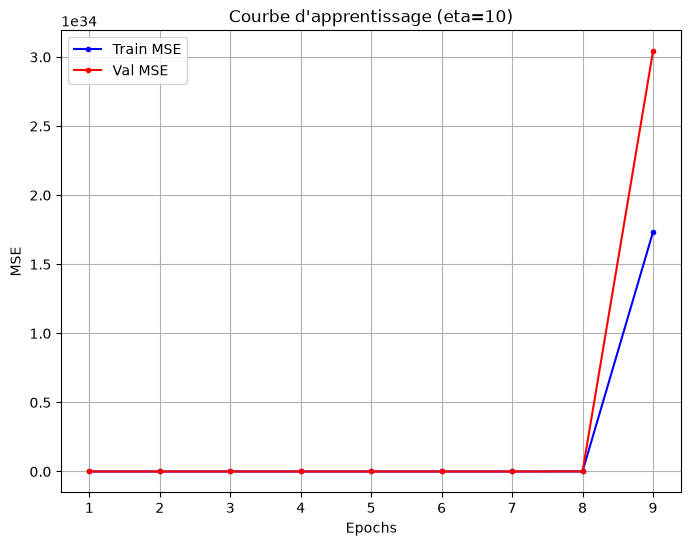

tensor([[-9.5583e+36],
        [ 9.4475e+34]])

In [9]:
# Suite exercice

# Réaliser une fonction permettant d'afficher la courbe d'apprentissage.
# Bonus: split train/val afin de visualiser les deux courbes
# Vous avez le droit de vous faire assister par IA

import torch
import matplotlib.pyplot as plt

m = 100
X = 2 * torch.randn(m, 1)
y = 4 + 3 * X + torch.randn(m, 1)


def plot_learning_curve(X, y, eta=0.1, n_epochs=100, val_split=0.2):
    """
    Affiche la courbe d'apprentissage (erreur train/val) pour une régression linéaire
    avec descente de gradient.

    Args:
        X (torch.Tensor): Données d'entrée, shape (m,1)
        y (torch.Tensor): Cibles, shape (m,1)
        eta (float): Learning rate
        n_epochs (int): Nombre d'itérations
        val_split (float): Pourcentage de validation (0-1)
    """
    m = X.shape[0]

    # --- Split train / validation ---
    val_size = int(m * val_split)
    idx = torch.randperm(m)  # shuffle
    val_idx = idx[:val_size]
    train_idx = idx[val_size:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # Ajout du biais
    X_train_b = torch.hstack([X_train, torch.ones((X_train.shape[0], 1))])
    X_val_b   = torch.hstack([X_val,   torch.ones((X_val.shape[0], 1))])

    # Initialisation des paramètres
    thetas = torch.randn(X_train_b.shape[1],1)

    # Historique des erreurs
    train_errors = []
    val_errors = []

    for epoch in range(n_epochs):
        # --- Forward ---
        y_pred = X_train_b @ thetas
        error = y_pred - y_train

        # --- Gradient ---
        gradients = 2 / X_train.shape[0] * (X_train_b.T @ error)
        thetas -= eta * gradients

        # --- Loss train ---
        train_mse = torch.mean((y_train - X_train_b @ thetas)**2).item()
        train_errors.append(train_mse)

        # --- Loss val ---
        val_mse = torch.mean((y_val - X_val_b @ thetas)**2).item()
        val_errors.append(val_mse)

    # --- Plot courbes ---
    print(thetas)
    plt.figure(figsize=(8,6))
    plt.plot(range(1, n_epochs+1), train_errors, label="Train MSE", color="blue", marker='.')
    plt.plot(range(1, n_epochs+1), val_errors, label="Val MSE", color="red", marker='.')
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title(f"Courbe d'apprentissage (eta={eta})")
    plt.legend()
    plt.grid(True)
    plt.show()

    return thetas
plot_learning_curve(X, y, eta=10, n_epochs=20, val_split=0.1)

# Intérêt de la mise à l'échelle

In [10]:
m = 100

X1 = 2 * torch.rand(m, 1)
X2 = 100 * torch.rand(m, 1)

X = torch.cat([X1, X2], dim=1)
X_scaled = torch.cat([(X1 - X1.mean(axis=0) )/ X1.std(axis=0), (X2 - X2.mean(axis=0) )/ X2.std(axis=0)], dim=1)

# Biais = 15.5, Poids de X1 = 2, Poids de X2 = 5.6
y = 15.5 + 2 * X1 + 5.6 * X2

# Faites tourner la fonction précédente sur ces nouvelles données,
# puis comparez avec les mêmes données mises à l’échelle (StandardScaler).
# Que remarquez-vous ?

tensor([[nan],
        [nan],
        [nan]])


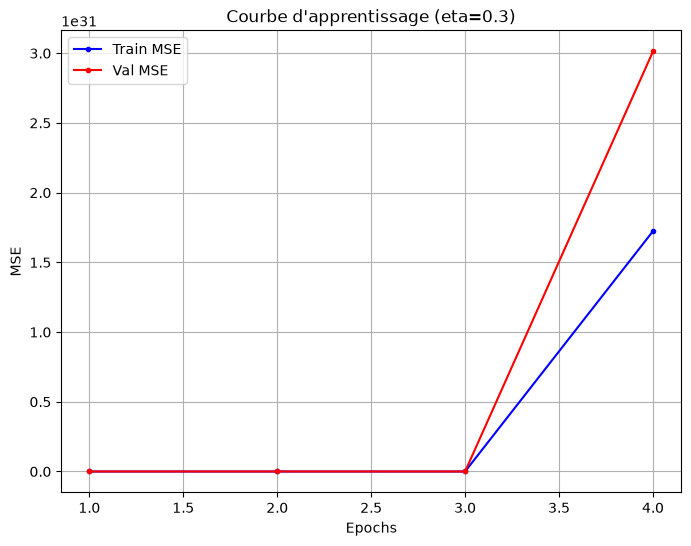

tensor([[nan],
        [nan],
        [nan]])

In [11]:
plot_learning_curve(X, y, eta=3e-1, n_epochs=50, val_split=0.1)

tensor([[  1.3380],
        [155.9925],
        [296.1323]])


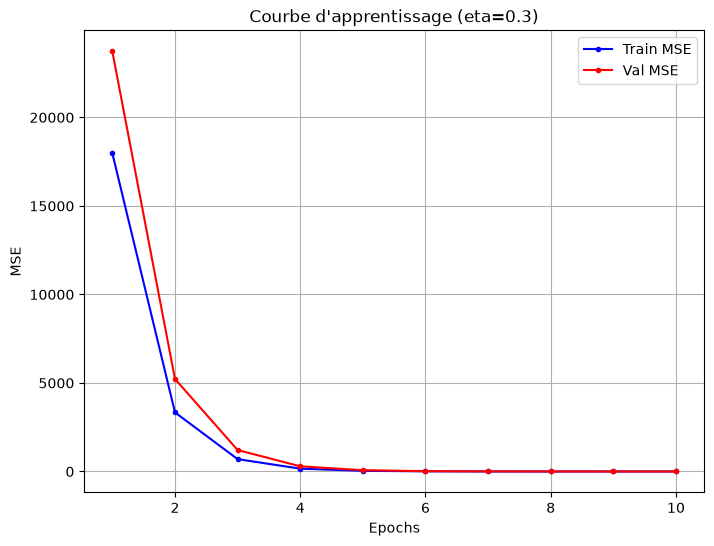

In [12]:
thetas = plot_learning_curve(X_scaled, y, eta=3e-1, n_epochs=10, val_split=0.1)

Le modèle entraîné sur `X_scaled` a trouvé cette équation :

$$ y = \theta'_1 \left( \frac{X_1 - \mu_1}{\sigma_1} \right) + \theta'_2 \left( \frac{X_2 - \mu_2}{\sigma_2} \right) + \theta'_{biais} $$

Si on développe pour isoler $X_1$ et $X_2$, on obtient l'équation sur les variables d'origine :

$$ y = \left( \frac{\theta'_1}{\sigma_1} \right) X_1 + \left( \frac{\theta'_2}{\sigma_2} \right) X_2 + \left( \theta'_{biais} - \frac{\theta'_1 \mu_1}{\sigma_1} - \frac{\theta'_2 \mu_2}{\sigma_2} \right) $$

In [13]:
# Pour passer des paramètres trouvés sur les données mise à l'échelle à ceux d'origine il faut : 
mu1, std1 = X1.mean().item(), X1.std().item()
mu2, std2 = X2.mean().item(), X2.std().item()

theta1_scaled = thetas[0]    # Poids pour X1_scaled
theta2_scaled = thetas[1] # Poids pour X2_scaled
bias_scaled   = thetas[2]  # Biais_scaled (dernier élément de thetas)

# 1. Conversion des poids
theta1_orig = theta1_scaled / std1
theta2_orig = theta2_scaled / std2

# 2. Conversion du biais
bias_orig = bias_scaled - (theta1_orig * mu1) - (theta2_orig * mu2)

print(f"Poids d'origine reconstitués :")
print(f"Poids X1 : {theta1_orig.item():.2f} (Attendu : ~2.0)")
print(f"Poids X2 : {theta2_orig.item():.2f} (Attendu : ~5.6)")
print(f"Biais    : {bias_orig.item():.2f} (Attendu : ~15.5)")

Poids d'origine reconstitués :
Poids X1 : 2.30 (Attendu : ~2.0)
Poids X2 : 5.59 (Attendu : ~5.6)
Biais    : 15.41 (Attendu : ~15.5)


### Stochastic Gradient Descent

In [14]:
# Exerice : Adapter la batch gradient descente à la stochastic gradient descent

m = 100
X = 5 * torch.randn(m, 1)
y = 4 + 3 * X + torch.randn(m, 1)
X_b = torch.hstack([X, torch.ones((m, 1))])

eta = 0.01
n_epochs = 100

thetas = torch.randn(2, 1)
for i in range(n_epochs):
    idx_shuffled = torch.randperm(m)
    for idx in idx_shuffled:
        gradients = 2 * torch.matmul(X_b[idx, None].T, torch.matmul(X_b[idx, None], thetas)-y[idx, :])
        thetas = thetas - eta*gradients
    print(thetas)

tensor([[2.7715],
        [3.2116]])
tensor([[3.0413],
        [4.1421]])
tensor([[3.0163],
        [4.0751]])
tensor([[3.1120],
        [4.1265]])
tensor([[3.3057],
        [4.3023]])
tensor([[3.1819],
        [4.5646]])
tensor([[2.8472],
        [4.1922]])
tensor([[2.9215],
        [4.2318]])
tensor([[2.8493],
        [4.2292]])
tensor([[3.1137],
        [4.3048]])
tensor([[2.5369],
        [4.1154]])
tensor([[3.0178],
        [4.0647]])
tensor([[3.1845],
        [4.2093]])
tensor([[3.1957],
        [4.0988]])
tensor([[2.2528],
        [4.1271]])
tensor([[3.0343],
        [4.2680]])
tensor([[2.9882],
        [4.1327]])
tensor([[2.6917],
        [4.0786]])
tensor([[3.2513],
        [4.2290]])
tensor([[2.6618],
        [4.0913]])
tensor([[3.0770],
        [4.0300]])
tensor([[1.8894],
        [3.9120]])
tensor([[2.9976],
        [4.2322]])
tensor([[2.9723],
        [3.9798]])
tensor([[4.0707],
        [3.8964]])
tensor([[2.9525],
        [4.1268]])
tensor([[2.8961],
        [4.0281]])
t

Thetas trouvés : 
 tensor([[3.0625],
        [4.0484]])


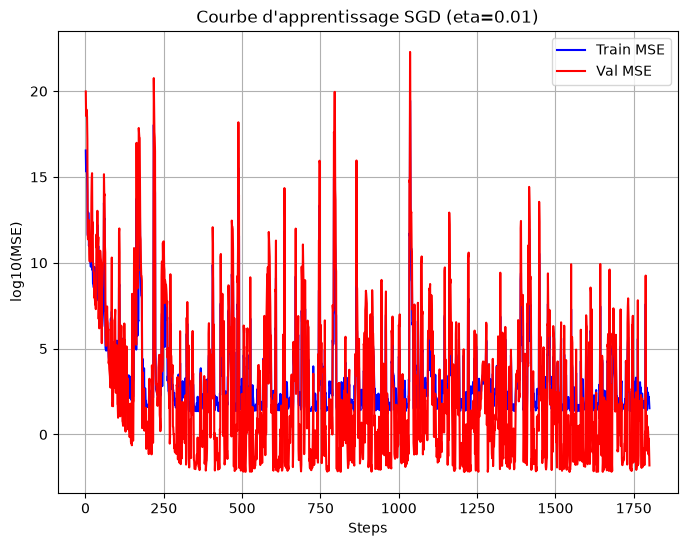

In [15]:
def plot_learning_curve_SGD(X, y, eta=0.1, n_epochs=100, val_split=0.2):
    """
    Affiche la courbe d'apprentissage (erreur train/val) pour une régression linéaire
    avec descente de gradient stochastique (SGD).

    Args:
        X (torch.Tensor): Données d'entrée, shape (m, n)
        y (torch.Tensor): Cibles, shape (m, 1)
        eta (float): Learning rate
        n_epochs (int): Nombre d'itérations sur tout le dataset
        val_split (float): Pourcentage de validation (0-1)
    """
    m = X.shape[0]

    # --- Split train / validation ---
    val_size = int(m * val_split)
    idx = torch.randperm(m)  # shuffle
    val_idx = idx[:val_size]
    train_idx = idx[val_size:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # Ajout du biais
    X_train_b = torch.hstack([X_train, torch.ones((X_train.shape[0], 1))])
    X_val_b   = torch.hstack([X_val,   torch.ones((X_val.shape[0], 1))])

    # Initialisation des paramètres
    thetas = torch.randn(X_train_b.shape[1], 1)

    # Historique des erreurs
    train_errors = []
    
    val_errors = []

    n_steps = 0
    for _ in range(n_epochs):
        idx_shuffled = torch.randperm(X_train_b.shape[0])
        for idx in idx_shuffled:
            n_steps += 1
            
            # Extraction d'une seule instance (le None permet de garder la dimension 2D)
            xi = X_train_b[idx, None]
            yi = y_train[idx, None]
            
            # --- Forward ---
            y_pred = xi @ thetas
            error = y_pred - yi

            # --- Gradient Stochastique ---
            # Suppression de la ligne erronée contenant X_b
            gradients = 2 * (xi.T @ error)
            thetas -= eta * gradients

            # --- Loss train ---
            # Attention: calculer la MSE complète à chaque step ralentit beaucoup l'exécution, 
            # mais c'est utile ici pour tracer la courbe détaillée
            train_mse = torch.mean((y_train - X_train_b @ thetas)**2).item()
            train_errors.append(train_mse)

            # --- Loss val ---
            val_mse = torch.mean((y_val - X_val_b @ thetas)**2).item()
            val_errors.append(val_mse)

    # --- Plot courbes ---
    print("Thetas trouvés : \n", thetas)
    
    plt.figure(figsize=(8,6))
    
    plt.plot(range(1, n_steps+1), 10*torch.log10(torch.tensor(train_errors)+1e-7), label="Train MSE", color="blue")
    plt.plot(range(1, n_steps+1), 10*torch.log10(torch.tensor(val_errors)+1e-7), label="Val MSE", color="red")
    plt.xlabel("Steps")
    plt.ylabel("log10(MSE)")
    plt.title(f"Courbe d'apprentissage SGD (eta={eta})")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve_SGD(X, y, eta=0.01, n_epochs=20, val_split=0.1)

### Mini-Batch Gradient Descent

In [16]:
# Exerice : Adapter la stochastic gradient descente à la mini-batch gradient descent

batch_size = 32

thetas = torch.randn(2, 1)
for i in range(n_epochs):
    idx_shuffled = torch.randperm(m)
    for i in range(m//batch_size):
        idx_start = i * batch_size
        idx_end = (i+1)*batch_size
        gradients = 2/batch_size * torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :].T, torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :], thetas)-y[idx_shuffled[idx_start:idx_end], :])
        thetas = thetas - eta*gradients
    print(thetas)

tensor([[2.5213],
        [0.8740]])
tensor([[2.9498],
        [1.0657]])
tensor([[3.0496],
        [1.2448]])
tensor([[3.0311],
        [1.4148]])
tensor([[2.9864],
        [1.5739]])
tensor([[3.0068],
        [1.7240]])
tensor([[3.0323],
        [1.8667]])
tensor([[3.0127],
        [1.9974]])
tensor([[3.0330],
        [2.1201]])
tensor([[3.0535],
        [2.2366]])
tensor([[3.0477],
        [2.3461]])
tensor([[3.0562],
        [2.4526]])
tensor([[3.0351],
        [2.5515]])
tensor([[3.0193],
        [2.6441]])
tensor([[2.9998],
        [2.7318]])
tensor([[3.0319],
        [2.8118]])
tensor([[3.0555],
        [2.8886]])
tensor([[3.0584],
        [2.9593]])
tensor([[3.0209],
        [3.0299]])
tensor([[3.0348],
        [3.0939]])
tensor([[3.0122],
        [3.1527]])
tensor([[3.0317],
        [3.2098]])
tensor([[3.0349],
        [3.2630]])
tensor([[3.0122],
        [3.3127]])
tensor([[3.0197],
        [3.3620]])
tensor([[3.0225],
        [3.4065]])
tensor([[3.0235],
        [3.4512]])
t

Thetas trouvés : 
 tensor([[3.0135],
        [2.1306]])


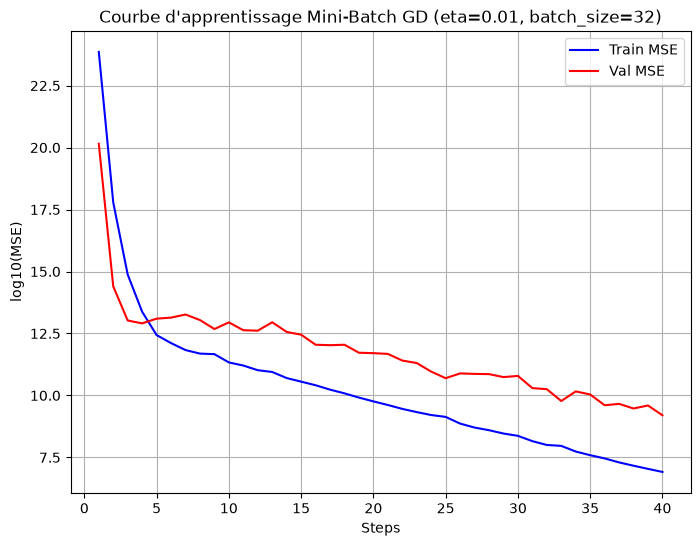

In [17]:
def plot_learning_curve_MiniBGD(X, y, eta=0.1, n_epochs=100, val_split=0.2, batch_size=32):
    """
    Affiche la courbe d'apprentissage (erreur train/val) pour une régression linéaire
    avec descente de gradient mini-batch.

    Args:
        X (torch.Tensor): Données d'entrée, shape (m, n)
        y (torch.Tensor): Cibles, shape (m, 1)
        eta (float): Learning rate
        n_epochs (int): Nombre d'itérations sur tout le dataset
        val_split (float): Pourcentage de validation (0-1)
        batch_size (int): Taille des mini-batchs
    """
    m = X.shape[0]

    # --- Split train / validation ---
    val_size = int(m * val_split)
    idx = torch.randperm(m)  # shuffle
    val_idx = idx[:val_size]
    train_idx = idx[val_size:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # Ajout du biais
    X_train_b = torch.hstack([X_train, torch.ones((X_train.shape[0], 1))])
    X_val_b   = torch.hstack([X_val,   torch.ones((X_val.shape[0], 1))])

    m_train = X_train_b.shape[0]

    # Initialisation des paramètres
    thetas = torch.randn(X_train_b.shape[1], 1)

    # Historique des erreurs
    train_errors = []
    val_errors = []

    n_steps = 0
    for _ in range(n_epochs):
        idx_shuffled = torch.randperm(m_train)
        for i in range(m_train // batch_size):
            n_steps += 1

            # Extraction d'un mini-batch
            idx_start = i * batch_size
            idx_end = (i + 1) * batch_size
            batch_idx = idx_shuffled[idx_start:idx_end]
            xi = X_train_b[batch_idx, :]
            yi = y_train[batch_idx, :]

            # --- Forward ---
            y_pred = xi @ thetas
            error = y_pred - yi

            # --- Gradient Mini-Batch ---
            gradients = 2 / batch_size * (xi.T @ error)
            thetas -= eta * gradients

            # --- Loss train ---
            train_mse = torch.mean((y_train - X_train_b @ thetas)**2).item()
            train_errors.append(train_mse)

            # --- Loss val ---
            val_mse = torch.mean((y_val - X_val_b @ thetas)**2).item()
            val_errors.append(val_mse)

    # --- Plot courbes ---
    print("Thetas trouvés : \n", thetas)

    plt.figure(figsize=(8,6))
    plt.plot(range(1, n_steps+1), 10*torch.log10(torch.tensor(train_errors)+1e-7), label="Train MSE", color="blue")
    plt.plot(range(1, n_steps+1), 10*torch.log10(torch.tensor(val_errors)+1e-7), label="Val MSE", color="red")
    plt.xlabel("Steps")
    plt.ylabel("log10(MSE)")
    plt.title(f"Courbe d'apprentissage Mini-Batch GD (eta={eta}, batch_size={batch_size})")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve_MiniBGD(X, y, eta=0.01, n_epochs=20, val_split=0.1)

# Logistic Regression

In [18]:
from sklearn.datasets import load_breast_cancer
import torch
X, y = load_breast_cancer(as_frame=True, return_X_y=True)

In [19]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [20]:
import numpy as np
np.unique(y, return_counts=True)

(array([0, 1]), array([212, 357]))

In [21]:
X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.float32)

In [22]:
X_b = torch.hstack([(X - X.mean(axis=0)) / X.std(axis=0), torch.ones(X.shape[0], 1)])

X_b.shape

torch.Size([569, 31])

In [23]:
# Exercice : Modifier la linear regression pour réaliser de la logistic regression
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

m = 100
n_epochs = 50
eta = 0.1
batch_size = 16
num_features = X_b.shape[1]
thetas = torch.randn(num_features, 1)
for i in range(n_epochs):
    idx_shuffled = torch.randperm(m)
    for i in range(m//batch_size):
        idx_start = i * batch_size
        idx_end = (i+1)*batch_size
        gradients = 1/batch_size * torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :].T, sigmoid(torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :], thetas))-y[idx_shuffled[idx_start:idx_end], None])
        thetas = thetas - eta*gradients
    print(thetas)

tensor([[-0.1017],
        [-0.8455],
        [-1.3869],
        [-0.6970],
        [ 0.6651],
        [ 1.0946],
        [-0.4440],
        [-1.3982],
        [-2.4163],
        [ 1.4856],
        [-0.2965],
        [ 0.4359],
        [ 0.2115],
        [ 0.8795],
        [-0.0495],
        [-0.1854],
        [ 0.3193],
        [-2.7685],
        [-0.2149],
        [ 0.3400],
        [ 0.8220],
        [ 1.0886],
        [-2.2610],
        [ 1.2890],
        [ 0.0666],
        [ 1.8496],
        [ 0.2178],
        [ 0.1028],
        [ 0.6118],
        [-2.4738],
        [-1.8009]])
tensor([[-0.1518],
        [-0.9142],
        [-1.4391],
        [-0.7438],
        [ 0.6548],
        [ 1.0401],
        [-0.4850],
        [-1.4461],
        [-2.3672],
        [ 1.4821],
        [-0.3130],
        [ 0.4510],
        [ 0.1889],
        [ 0.8528],
        [-0.0173],
        [-0.1960],
        [ 0.3452],
        [-2.7496],
        [-0.1425],
        [ 0.3537],
        [ 0.7583],
        [ 1

In [24]:
(((X_b @ thetas > 0.5) * 1.0 == y[..., None]) * 1.0).mean() * 100

tensor(91.5641)

# Softmax Regression

In [25]:
from sklearn.datasets import load_iris
import torch

X, y = load_iris(as_frame=True, return_X_y=True)

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [27]:
X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.int64).to(device)

X_b = torch.hstack([(X - X.mean(axis=0)) / X.std(axis=0), torch.ones(X.shape[0], 1)]).to(device)
X_b.shape

torch.Size([150, 5])

In [28]:
y

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2], device='cuda:0')

In [29]:
num_features = X_b.shape[1]
num_classes = torch.unique(y).shape[0]

In [30]:
y = torch.nn.functional.one_hot(y, num_classes=num_classes).float()

In [31]:
def softmax(x): 
    exp_x = torch.exp(x) 
    return exp_x / exp_x.sum(axis=1)[..., None]

batch_size = 16
eta = 1e-1
n_epochs = 10000
m = X_b.shape[0]
thetas = torch.randn(num_features, num_classes).to(device)
for i in range(n_epochs):
    idx_shuffled = torch.randperm(m)
    for i in range(m//batch_size):
        idx_start = i * batch_size
        idx_end = (i+1)*batch_size
        p_hat = softmax(torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :], thetas))
        gradients = 1/batch_size * X_b[idx_shuffled[idx_start:idx_end], :].T @ (p_hat - y[idx_shuffled[idx_start:idx_end], :])
        thetas = thetas - eta*gradients
    # print(thetas)

    print(round(((torch.argmax((X_b @ thetas), dim=-1) == torch.argmax(y, dim=-1)) * 1.0).mean().item() * 100, 2))  # métriques !
    

65.33
66.67
66.67
66.67
70.0
78.67
83.33
84.67
85.33
87.33
88.67
90.0
90.0
90.0
90.67
91.33
91.33
90.67
91.33
91.33
91.33
90.67
92.0
92.0
92.67
94.0
93.33
93.33
93.33
93.33
93.33
93.33
94.0
94.0
94.0
94.0
94.0
94.0
94.0
94.0
94.0
94.67
94.67
94.67
94.67
94.67
94.67
95.33
95.33
95.33
95.33
95.33
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.67
96.67
96.67
96.67
96.0
96.0
96.67
96.67
96.67
96.67
96.67
96.67
96.67
96.67
96.67
96.67
96.67
96.67
96.67
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33


### Exercice — Effet du *learning rate* sur la convergence
Implementez une descente de gradient batch pour une régression linéaire simple et comparez la convergence pour plusieurs learning rates. Un LR trop grand **diverge**, un LR trop petit **converge lentement**.

Faites le sur n'importe quel algorithme et avec n'importe quelle données


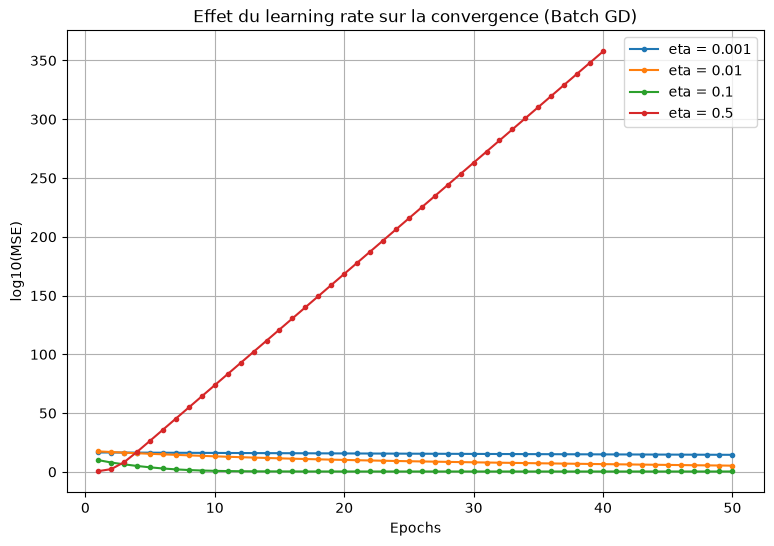

In [32]:
# Solution : effet du learning rate sur la convergence (batch gradient descent)

import torch
import matplotlib.pyplot as plt

torch.manual_seed(123)

# --- Données linéaires bruitées ---
m = 100
X = 2 * torch.randn(m, 1)
y = 4 + 3 * X + torch.randn(m, 1)

# Ajout du biais
X_b = torch.hstack([X, torch.ones((m, 1))])


def train_batch_gd(X_b, y, eta, n_epochs=50):
    """Descente de gradient batch ; retourne l'historique des MSE."""
    m = X_b.shape[0]
    thetas = torch.randn(X_b.shape[1], 1)
    errors = []
    for _ in range(n_epochs):
        gradients = 2 / m * (X_b.T @ (X_b @ thetas - y))
        thetas = thetas - eta * gradients
        mse = torch.mean((y - X_b @ thetas) ** 2).item()
        errors.append(mse)
    return errors


# --- Comparaison de plusieurs learning rates ---
learning_rates = [0.001, 0.01, 0.1, 0.5]  # de "trop petit" à "trop grand"
n_epochs = 50

plt.figure(figsize=(9, 6))
for eta in learning_rates:
    errors = train_batch_gd(X_b, y, eta=eta, n_epochs=n_epochs)
    # échelle log pour bien voir convergence lente ET divergence
    plt.plot(range(1, n_epochs + 1),
             10 * torch.log10(torch.tensor(errors) + 1e-7),
             marker='.', label=f"eta = {eta}")

plt.xlabel("Epochs")
plt.ylabel("log10(MSE)")
plt.title("Effet du learning rate sur la convergence (Batch GD)")
plt.legend()
plt.grid(True)
plt.show()

# Observations :
# - eta trop petit (0.001) : la MSE descend très lentement, pas encore convergé.
# - eta bien choisi (0.1)  : convergence rapide et stable vers le minimum.
# - eta trop grand (0.5)   : la MSE remonte / explose -> divergence.